<div align="center">
    <h1> Control Barrier Functions in Semi-Automated Beverage Blending Equipment<br> 
    <h3> Samantha Becvar <br> University of Washington, Department of Mechanical Engineering Master's Program <br> A A/E E/M E 548 B <br> Prof. Karen Leung
</div>

## **----Section 0: Imports----**

In [25]:
import jax.numpy as jnp
from jaxtyping import Float, Array
from typing import Any
import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 100.0
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

## **----Section 1: Build the System----** <br>
This section consists of defining:
* Functions to build the environment
* Functions to build the cup
* Functions to build the blender

#### Environment Functions
**Functions:**
* environment(ax, env_dims)
* black_box(ax, box_size, box_center)

In [26]:
def environment(ax: Axes, env_dims: Float[Array, "2 2"]) -> None:
    '''
    The purpose of this function is to create the base plot of our simulation environment. 
    It sets the limits of the x and y axes, adds a basic title, and displays a grid. 
    -----
    Args
        ax - axis, for plotting purposes
        env_dims - a 2x2 array that contains the x axis bounds and the y axis bounds of our environment
    Returns
        none
    '''
    # unpack the environmental dimensions into our x and y bounds
    x_bounds, y_bounds = env_dims   # [(x_min, x_max), (y_min, y_max)]

    # plot our x axis and our y axis
    ax.set_xlim(x_bounds[0], x_bounds[1])
    ax.set_ylim(y_bounds[0], y_bounds[1])

    # assign the plot to axis, set the title
    ax = plt.gca()
    ax.set_zorder(0)
    ax.set_title("Environment")

def black_box(ax: Axes, box_size: Float[Array, "2"], box_center: Float[Array, "2"]) -> None:
    '''
    The purpose of this function is to create a black box to plot in our simulation environment. 
    A box is defined by its width, height, and the coordinates of it's center.
    It is purely for aesthetic purposes. 
    -----
    Args
        ax - axis, for plotting purposes
        box_size - a 1x2 array that contains the width and height of a box
        box_center - a 1x2 array that contains the (x, y) center of a box
    Returns
        None
    '''
    # unpack our box_size and box_center arrays
    width, height = box_size
    cx, cy = box_center

    # define the lower left corner of the box for plotting with the "add_patch function"
    lower_left = (cx - width / 2, cy - height / 2)

    # define the box
    box = Rectangle(
        lower_left, # start in the lower left corner
        width,      # the width of the box
        height,     # the height of the box
        facecolor = 'black',
        edgecolor = None,
        zorder = 4
    )

    # add the box to the plot
    ax.add_patch(box)

#### Build the Cup
**Functions:**
* cup_geometry(cup_dims)
* cup(ax, cup_dims, product)

In [27]:
def cup_geometry(cup_dims: Float[Array, "4"]) -> dict[str, Any]:
    '''
    The purpose of this function is to create a dictionary of the cup geometry defined by the dimensions.
    This function is not called directly during simulation creation, it is purely used to define the dictionary.
    -----
    Args
        cup_dims - a 1x4 array that contains the width of the bottom of the cup, the width of the top of the cup, the center location, and the height of the cup
    Returns
        cup_geom - a dictionary of the cup geometry used for plotting and for controls reference points
    '''
    # unpack our cup dimensions
    bottom, top, center, height = cup_dims

    # (x, y) locations of our cup's corners
    bottom_left = jnp.array([center - bottom / 2, 0.0])
    bottom_right = jnp.array([center + bottom / 2, 0.0])    
    top_left = jnp.array([center - top / 2, height])
    top_right = jnp.array([center + top / 2, height])

    # crete the dictionary of geometry
    cup_geom = {
        # basic dimensions
        "bottom": bottom,
        "top": top,
        "center": center,
        "height": height,

        # corner coordinates
        "bottom_left": bottom_left,
        "bottom_right": bottom_right,
        "top_left": top_left,
        "top_right": top_right,

        # control references
        "cup_top_y": height,
        "cup_bottom_y" : 0.0, 
        "opening_left_x": top_left[0],
        "opening_right_x": top_right[0],
    }
    return cup_geom

def cup(ax: Axes, cup_dims: Float[Array, "4"], product: str) -> dict[str, Any]:
    '''
    The purpose of this function is to draw the cup in the environment.
    The cup is defined by the width of its bottom and top, the x coordinate of its center, and its height.
    The function also fills the cup with a color to represent the "product" that fills to (height - 0.5)
    -----
    Args
        ax - axis, for plotting purposes
        cup_dims - a 1x4 array that contains the width of the bottom of the cup, the width of the top of the cup, the center location, and the height of the cup
        product - a string of a color name to color the liquid
    Returns
        cup_geom - a dictionary of the cup geometry used for plotting and for controls reference points 
    '''
    # create our dictionary of cup geometry
    cup_geom = cup_geometry(cup_dims)

    #--DRAW CUP--
    # define our walls of the cup for plotting
    walls = jnp.array([
        cup_geom["top_left"],       # start at top left corner
        cup_geom["bottom_left"],    # draw to bottom left corner
        cup_geom["bottom_right"],   # draw to bottom right corner
        cup_geom["top_right"],      # end at top right corner
    ])

    # draw the cup
    ax.plot(
        walls[:, 0],
        walls[:, 1],
        color='black',
        linewidth=2,
        zorder = 3
    )
    
    #--DRAW PRODUCT--
    # define the fill height of the product (for plotting)
    fill_height = cup_geom["height"] - 0.5

    # define the width of the liquid surface at the fill height (for plotting)
    fill_top_width = cup_geom["bottom"] + (cup_geom["top"] - cup_geom["bottom"]) * (fill_height / cup_geom["height"])

    # define the liquid shape for plotting
    liquid = jnp.array([
        [cup_geom["center"] - cup_geom["bottom"] / 2, 0.0],     # (x, y) to define bottom left corner
        [cup_geom["center"] + cup_geom["bottom"] / 2, 0.0],     # (x, y) to define bottom right corner 
        [cup_geom["center"] + fill_top_width / 2, fill_height], # (x, y) to define top left corner
        [cup_geom["center"] - fill_top_width / 2, fill_height]  # (x, y) to define top right corner 
    ])

    # draw the liquid
    ax.fill(
        liquid[:, 0],
        liquid[:, 1],
        color=product,
        alpha=0.7,
        zorder = 2
    )
        
    return cup_geom

#### Stop and Check: Environment, Black Box, Cup
**Validate:**
* the generation and plotting of the environment function
* the generation and plotting of the black box function
* the generation and plotting of the cup

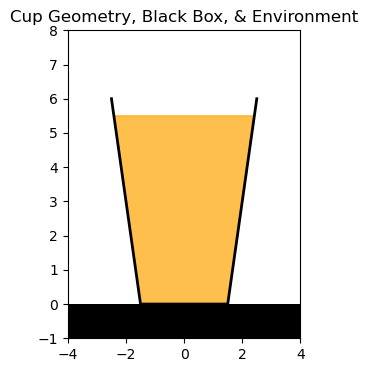

In [28]:
''' Definitions '''
# environment dimensions
env_dims_c1 = jnp.array([
    [-4, 4],    # (x_min, x_max)
    [-1, 8]    # (y_min, y_max)
])
# black box dimensions
box_size_c1 = jnp.array([
    8, # width
    1   # height
])
box_center_c1 = jnp.array([
    0,  # x center 
    -0.5  # y center
])
# cup dimensions
cup_dims_c1 = jnp.array([
    3,  # bottom width
    5,  # top width
    0,  # center location
    6   # height
])

''' Create the Plot '''
# create the figure and axis
fig_c1, ax_c1 = plt.subplots(figsize=(3, 4))

# call our plotting functions
environment(ax_c1, env_dims_c1)
black_box(ax_c1, box_size_c1, box_center_c1)
cup(ax_c1, cup_dims_c1, "orange")

# show the plot
ax_c1.grid(False)
plt.title("Cup Geometry, Black Box, & Environment")
plt.show()

#### Build the Blender
**Functions:**
* blender_geometry(blender_height)
* blender_shaft(ax, blender_geom)
* blender_bell(ax, blender_geom)
* blender(ax, blender_height)

In [29]:
def blender_geometry(blender_height: Float[Array, "1"]) -> dict[str, Any]:
    '''
    The purpose of this function is to create a dictionary of the blender geometry.
    This function is not called directly during simulation creation, it is purely used to define the dictionary.
    -----
    Args
        blender_height - a 1x1 array of the height of the tip of the blender bell
    Returns
        blender_geom - a dictionary of the blender geometry used for plotting and control reference points
    '''
    # define the static variables used to define the blender geometry 
    # blender shaft
    shaft_width = 2
    shaft_height = 28
    # blender bell
    bell_radius_x = 2
    bell_radius_y = 2.5
    bell_extension = 2.5

    # (x, y) location of the center of the blender bell
    bell_center = jnp.array([
        0.0,                    # x center location
        2.0 + blender_height    # y location
    ])

    # (x, y) locations of our blender shaft's corners
    shaft_bottom_left = jnp.array([-shaft_width / 2, bell_center[1]]) 
    shaft_bottom_right = jnp.array([shaft_width / 2, bell_center[1]])
    shaft_top_left = jnp.array([-shaft_width / 2, bell_center[1] + shaft_height])
    shaft_top_right = jnp.array([shaft_width / 2, bell_center[1] + shaft_height])
   
    # (x, y) location of the blender tip
    tip_position = jnp.array([
        bell_center[0],
        bell_center[1] - bell_extension
    ])

    # create the dictionary of geometry 
    blender_geom = {
        # Bell Geometry
        "bell_center": bell_center,
        "bell_radius_x": bell_radius_x,
        "bell_radius_y": bell_radius_y,
        "bell_extension": bell_extension,

        # Shaft Geometry 
        "shaft_bottom_left": shaft_bottom_left,
        "shaft_bottom_right": shaft_bottom_right,
        "shaft_top_left": shaft_top_left,
        "shaft_top_right": shaft_top_right,

        # Safety / Control Quantities
        "tip_position": tip_position,
        "tip_y": tip_position[1],
    }

    return blender_geom

def blender_shaft(ax: Axes, blender_geom: dict[str, Any]) -> None:
    ''' 
    The purpose of this function is to draw the shaft of the blender in the environment. 
    This function is not called directly during the simulation creation
    -----
    Args
        ax - axis, for plotting purposes
        blender_geom - a dictionary of the blender geometry for plotting and control purposes
    Returns
        None
    '''
    # define the shaft
    shaft = jnp.array([
        blender_geom["shaft_top_left"],     # start at top left corner
        blender_geom["shaft_bottom_left"],  # draw to bottom left corner
        blender_geom["shaft_bottom_right"], # draw to bottom right corner
        blender_geom["shaft_top_right"]     # end at top right corner
    ])

    # draw the shaft
    ax.fill(
        shaft[:, 0],
        shaft[:, 1],
        color = 'gray',
        alpha = 0.7,
        zorder = 1
    )

def blender_bell(ax: Axes, blender_geom: dict[str, Any]) -> None:
    ''' 
    The purpose of this function is to draw the bell of the blender in the environment. 
    This function is not called directly during the simulation creation
    -----
    Args
        ax - axis, for plotting purposes
        blender_geom - a dictionary of the blender geometry for plotting and control purposes
    Returns
        None
    '''
    # define the curve of the blender bell
    theta = jnp.linspace(0, jnp.pi, 100)

    # create the curved lines to draw the bell on a (x, y) coordinate grid
    x_curve = blender_geom["bell_center"][0] + blender_geom["bell_radius_x"] * jnp.cos(theta)
    y_curve = blender_geom["bell_center"][1] + blender_geom["bell_radius_y"] * jnp.sin(theta)

    # create the bell polygon by extending the curve downwards
    bell_extension = blender_geom["bell_extension"]

    # build the bell polygon by combining the curve and the extension
    left_x, left_y = x_curve[0], y_curve[0]
    right_x, right_y = x_curve[-1], y_curve[-1]
    left_bottom_y = left_y - blender_geom["bell_extension"]
    right_bottom_y = right_y - blender_geom["bell_extension"]

    # build one closed polygon for the bell by combining the curve and the extension
    bell_x = jnp.concatenate([
        jnp.array([left_x]),
        x_curve,
        jnp.array([right_x, right_x, left_x]),
    ])
    bell_y = jnp.concatenate([
        jnp.array([left_bottom_y]),
        y_curve,
        jnp.array([right_bottom_y, left_bottom_y, left_bottom_y]),
    ])

    # draw the blender bell
    ax.fill(
        bell_x, 
        bell_y, 
        color='gray', 
        alpha=0.7,
        zorder = 1
        )
 
def blender(ax: Axes, blender_height: Float[Array, "1"]) -> dict[str, Any]:
    '''
    The purpose of this function is to draw the complete blender in the environment.
    The blender is composed of the blender shaft and the blender bell. 
    This plot will be updated during simulations to show the "blending" action.
    -----
    Args
        ax - axis, for plotting purposes
        blender_height - a 1x1 array of the height of the tip of the blender bell
    Returns
        blender_geom - a dictionary of the blender geometry used for plotting and control reference points
    '''
    # create our dictionary of blender geometry 
    blender_geom = blender_geometry(blender_height)

    # create the blender plots
    blender_shaft(ax, blender_geom)
    blender_bell(ax, blender_geom)

    return blender_geom

#### Stop and Check: Blender
**Validate:**
* the generation and plotting of the blender function

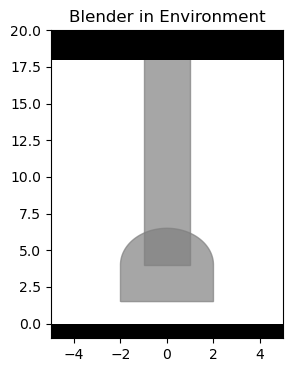

In [30]:
''' Definitions '''
# environment dimensions
env_dims_c2 = jnp.array([
    [-5, 5],    # (x_min, x_max)
    [-1, 20]    # (y_min, y_max)
])
# black box dimensions
box_size1_c2 = jnp.array([
    10,  # width
    1   # height
])
box_center1_c2 = jnp.array([
    0,      # x center 
    -0.5    # y center
])
box_size2_c2 = jnp.array([
    10,  # width
    2   # height
])
box_center2_c2 = jnp.array([
    0,  # x center
    19   # y center
])
box_sizes_c2 = jnp.array([
    box_size1_c2,
    box_size2_c2
])
box_centers_c2 = jnp.array([
    box_center1_c2,
    box_center2_c2
])
# blender height
blender_height_c2 = 2.0

''' Create the Plot '''
# create the figure and axis
fig_c2, ax_c2 = plt.subplots(figsize=(3, 4))

# call our plotting functions
environment(ax_c2, env_dims_c2)
for size, center in zip(box_sizes_c2, box_centers_c2):
    black_box(ax_c2, size, center)
blender(ax_c2, blender_height_c2)

# show the plot
ax_c2.grid(False)
plt.title("Blender in Environment")
plt.show()

#### Draw Environment Components
**Functions:**
* draw_environment(ax, env_dims, box_size, box_center, cup_dims, product)

In [31]:
def draw_environment(
        ax: Axes, 
        env_dims: Float[Array, "2, 2"], 
        box_size: Float[Array, "2"], 
        box_center: Float[Array, "2"],
        cup_dims: Float[Array, "4"],
        product: str
        ) -> None:
    '''
    The purpose of this section is to have one function to draw all of the stationary components in our environment. 
    -----
    Args
        ax - axis, for plotting purposes
        env_dims - a 2x2 array that contains the x axis bounds and the y axis bounds of our environment
        box_size - a 1x2 array that contains the width and height of a box
        box_center - a 1x2 array that contains the (x, y) center of a box
        cup_dims - a 1x4 array that contains the width of the bottom of the cup, the width of the top of the cup, the center location, and the height of the cup
        product - a string containing the color of the product
    Returns
        none
    '''
    # draw the environment
    environment(ax, env_dims)

    # draw the black boxes to define our environment
    for size, center in zip(box_size, box_center):
        black_box(ax, size, center)

    # draw the cup
    cup(ax, cup_dims, product)

#### Stop & Check: Build the Full Simulation Environment
**Validate:**
* the generation and plotting of the environment function
* the generation and plotting of the black box function
* the generation and plotting of the cup
* the generation and plotting of the blender

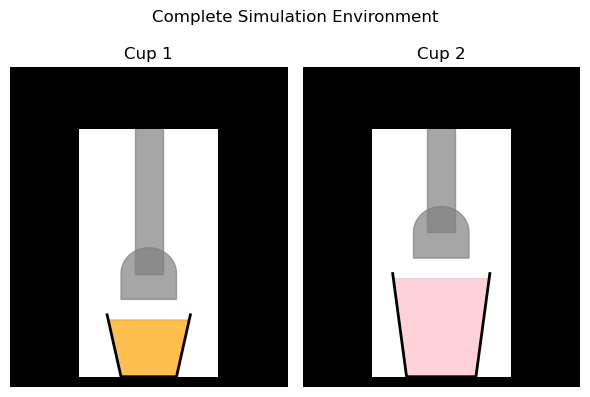

In [32]:
''' Definitions '''
# environment dimensions
env_dims_c3 = jnp.array([
    [-10, 10],    # (x_min, x_max)
    [-1, 30]    # (y_min, y_max)
])
# black box dimensions
box_sizes_c3 = jnp.array([
    [10, 1],    # bottom box, (width, height)
    [14, 6],    # top box, (width, height)
    [5, 32],    # left box, (width, height)
    [5, 32]    # right box, (width, height)
])
box_centers_c3 = jnp.array([
    [0, -0.5],  # bottom box, (center_x, center_y)
    [0, 27],    # top box, (center_x, center_y) 
    [-7.5, 14], # left box, (center_x, center_y)
    [7.5, 14]  # right box, (center_x, center_y)
])
# cup dimensions
cup_dims1_c3 = jnp.array([
    4,  # bottom width
    6,  # top width
    0,  # center location
    6   # height
])
cup_dims2_c3 = jnp.array([
    5,  # bottom width
    7,  # top width
    0,  # center location
    10  # height
])
# blender height
blender_height1_c3 = 8.0
blender_height2_c3 = 12.0

''' Create the Plot '''
# create the figure and axis
fig_c3, (ax1_c3, ax2_c3) = plt.subplots(1, 2, figsize=(6, 4))

# call our plotting functions for the first environment
draw_environment(ax1_c3, env_dims_c3, box_sizes_c3, box_centers_c3, cup_dims1_c3, "orange")
blender(ax1_c3, blender_height1_c3)
ax1_c3.grid(False)
ax1_c3.axis("off")
ax1_c3.set_title("Cup 1")

# call our plotting functions for the second environment
draw_environment(ax2_c3, env_dims_c3, box_sizes_c3, box_centers_c3, cup_dims2_c3, "pink")
blender(ax2_c3, blender_height2_c3)
ax2_c3.grid(False)
ax2_c3.axis("off")
ax2_c3.set_title("Cup 2")

fig_c3.suptitle("Complete Simulation Environment")
plt.tight_layout()
plt.show()